<a href="https://colab.research.google.com/github/fatouu50/Time-Series-Forecasting-ML/blob/main/Mois_1_Time_Series_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Step 1 : charger le fichier

In [1]:
import pandas as pd

df  = pd.read_csv('train.csv')

df.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


## Step 2 : Mettre la date au bon format et trier

In [2]:
df['date'] = pd.to_datetime(df['date'])

df = df.sort_values('date')  #fonction pour trier

df.head()

,date,store,item,sales
0,2013-01-01,1,1,13
211816,2013-01-01,7,12,26
832656,2013-01-01,7,46,27
213642,2013-01-01,8,12,54
215468,2013-01-01,9,12,35


## Step 3 : Nettoyer

In [3]:
df.isnull().sum() #valeurs manquantes

,0
date,0
store,0
item,0
sales,0


In [4]:
df.duplicated().sum()  #doublons

np.int64(0)

## Step 4 : Regarder les bases

In [5]:
df['store'].nunique()  #number of unique

10

In [6]:
df['item'].nunique()

50

In [7]:
df['date'].min()

Timestamp('2013-01-01 00:00:00')

In [9]:
df['date'].max()

Timestamp('2017-12-31 00:00:00')

In [10]:
df.shape  #rows & columns

(913000, 4)

In [12]:
df.columns  #noms de toutes les colonnes.

Index(['date', 'store', 'item', 'sales'], dtype='object')

In [13]:
df.dtypes #type of columns

,0
date,datetime64[ns]
store,int64
item,int64
sales,int64


In [14]:
df['sales'].describe()  #résumé statistique

,sales
count,913000.000000
mean,52.250287
std,28.801144
min,0.000000
25%,30.000000
50%,47.000000
75%,70.000000
max,231.000000


In [15]:
df['store'].value_counts() #Compte combien de fois chaque valeur apparaît

,count
store,
1,91300
7,91300
8,91300
9,91300
10,91300
6,91300
2,91300
5,91300
3,91300


## Univarié sur sales (variable quantitative → chiffres + forme)

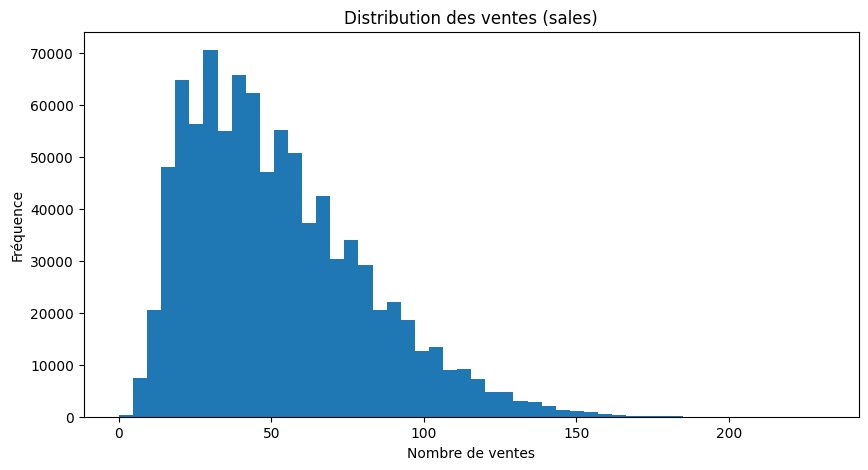

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(df['sales'], bins=50)
plt.title('Distribution des ventes (sales)')
plt.xlabel('Nombre de ventes')
plt.ylabel('Fréquence')
plt.show()

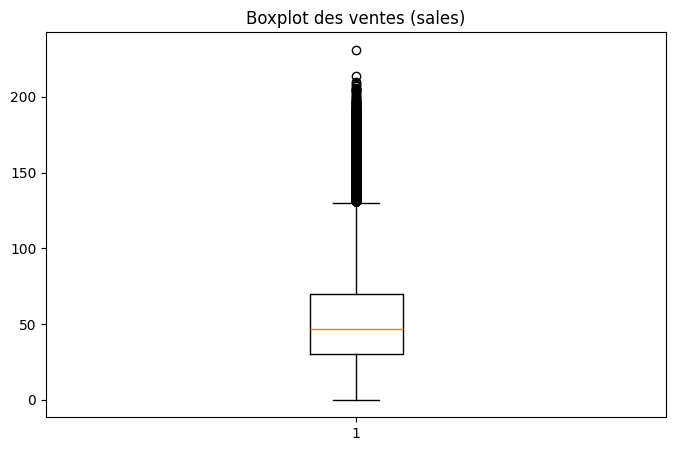

In [18]:
plt.figure(figsize=(8, 5))
plt.boxplot(df['sales'])
plt.title('Boxplot des ventes (sales)')
plt.show()

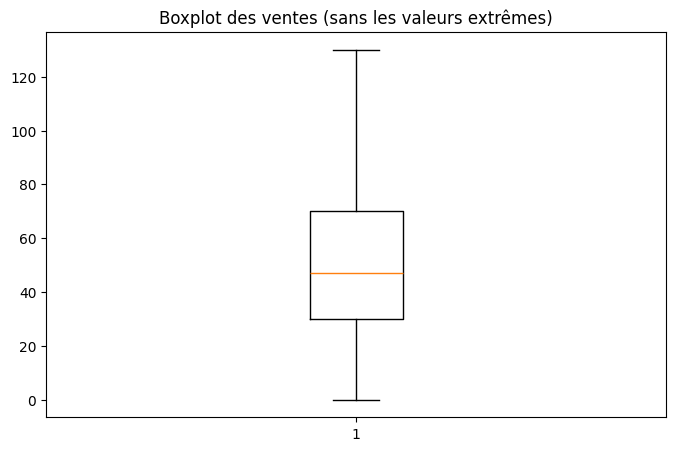

In [21]:
plt.figure(figsize=(8, 5))
plt.boxplot(df['sales'], showfliers=False)  # showfliers=False cache les points outliers, pour se concentrer sur la boîte principale (25%-75%).
plt.title('Boxplot des ventes (sans les valeurs extrêmes)')
plt.show()

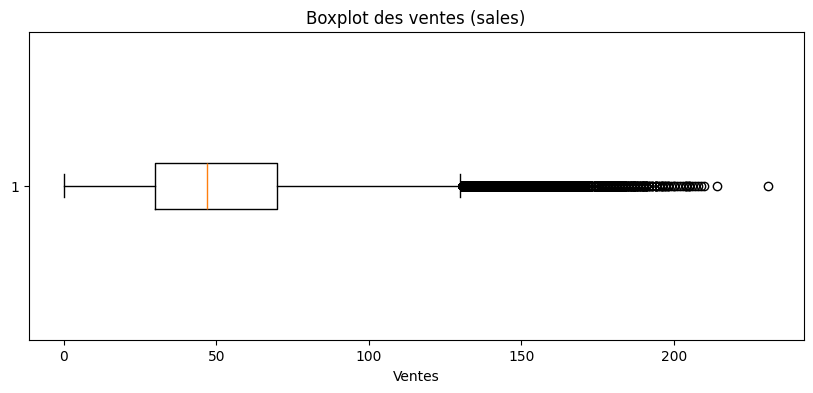

In [22]:
plt.figure(figsize=(10, 4)) #Boxplot horizontal (souvent plus lisible) :
plt.boxplot(df['sales'], vert=False)
plt.title('Boxplot des ventes (sales)')
plt.xlabel('Ventes')
plt.show()

## Univarié sur date (vérifier qu'aucun jour ne manque)

In [19]:
date_debut = df['date'].min()
date_fin = df['date'].max()
nb_jours_theorique = (date_fin - date_debut).days + 1
nb_jours_reels = df['date'].nunique()

print("Date de début :", date_debut)
print("Date de fin :", date_fin)
print("Jours théoriques :", nb_jours_theorique)
print("Jours réels présents :", nb_jours_reels)

Date de début : 2013-01-01 00:00:00
Date de fin : 2017-12-31 00:00:00
Jours théoriques : 1826
Jours réels présents : 1826


## Univarié sur store (variable catégorielle → comptage)

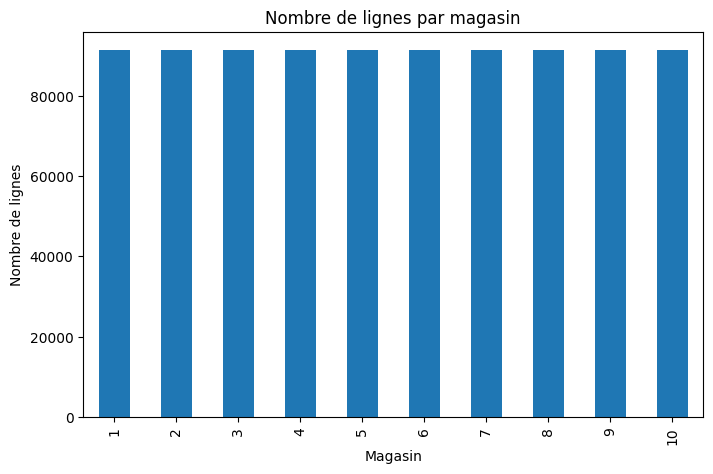

In [20]:
plt.figure(figsize=(8, 5))
df['store'].value_counts().sort_index().plot(kind='bar')
plt.title("Nombre de lignes par magasin")
plt.xlabel('Magasin')
plt.ylabel('Nombre de lignes')
plt.show()

### Petit rappel de la logique derrière chaque variable :

sales → quantité → on regarde distribution, moyenne, outliers.

date → temporel → on vérifie continuité, pas de trou.

store et item → catégories → on regarde combien de valeurs différentes, et

combien de fois chacune apparaît.

# On passe à l'analyse bivariée.

Rappel : ici on compare sales avec une autre variable, pour voir comment les
ventes changent selon cette variable.

## sales selon le jour de la semaine

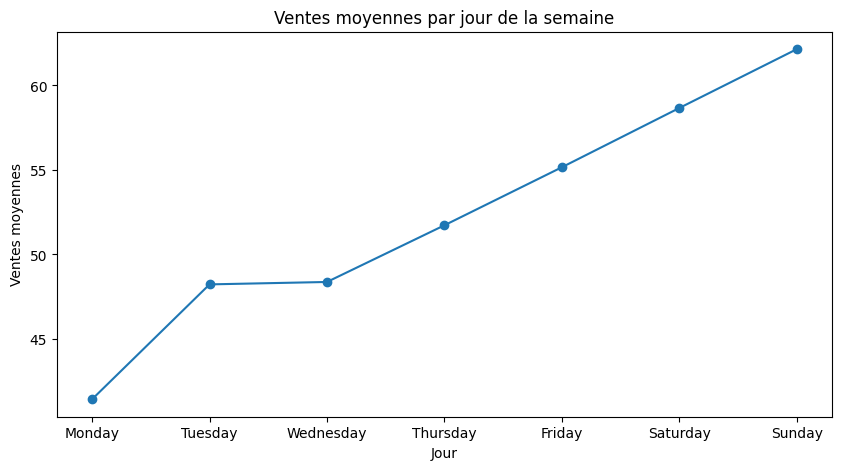

In [23]:
df['jour_semaine'] = df['date'].dt.day_name()

ventes_par_jour_semaine = df.groupby('jour_semaine')['sales'].mean()

ordre = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
ventes_par_jour_semaine = ventes_par_jour_semaine.reindex(ordre)

plt.figure(figsize=(10, 5))
ventes_par_jour_semaine.plot(kind='line', marker='o')
plt.title('Ventes moyennes par jour de la semaine')
plt.xlabel('Jour')
plt.ylabel('Ventes moyennes')
plt.show()

## sales selon le mois (saisonnalité annuelle)

<Figure size 1000x500 with 0 Axes>

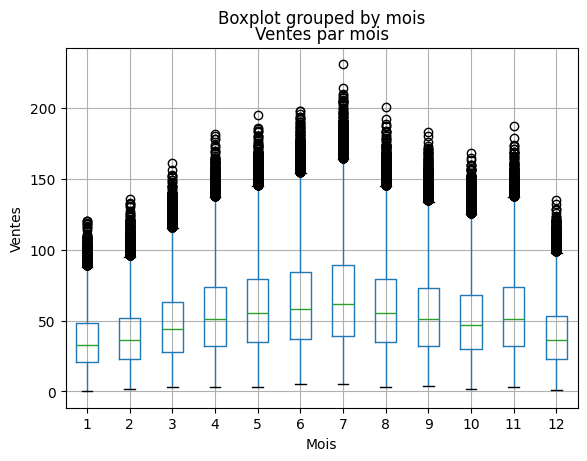

In [24]:
df['mois'] = df['date'].dt.month

plt.figure(figsize=(10, 5))
df.boxplot(column='sales', by='mois')
plt.title('Ventes par mois')
plt.xlabel('Mois')
plt.ylabel('Ventes')
plt.show()

## sales selon le magasin (store)

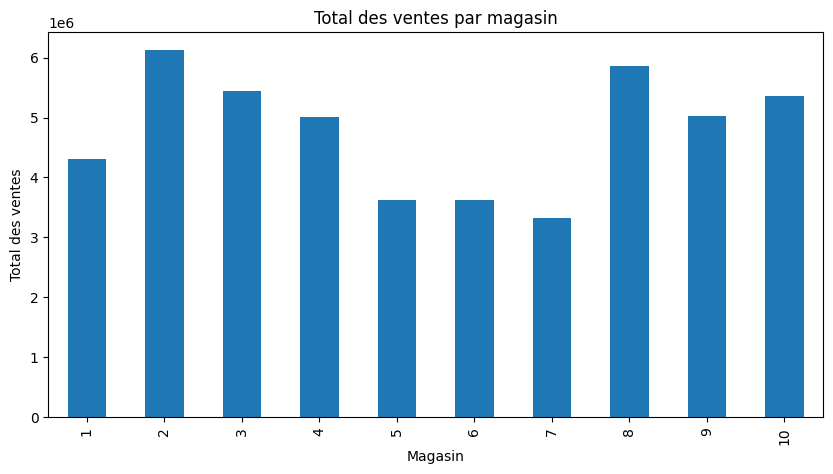

In [25]:
ventes_par_magasin = df.groupby('store')['sales'].sum()

plt.figure(figsize=(10, 5))
ventes_par_magasin.plot(kind='bar')
plt.title('Total des ventes par magasin')
plt.xlabel('Magasin')
plt.ylabel('Total des ventes')
plt.show()

## sales selon l'article (item) — top et flop

In [26]:
ventes_par_article = df.groupby('item')['sales'].sum().sort_values(ascending=False)

print("Top 5 articles les plus vendus :")
print(ventes_par_article.head())

print("\nTop 5 articles les moins vendus :")
print(ventes_par_article.tail())

Top 5 articles les plus vendus :
item
15    1607442
28    1604713
13    1539621
18    1538876
25    1473334
Name: sales, dtype: int64

Top 5 articles les moins vendus :
item
4     401907
47    401781
41    401759
1     401384
5     335230
Name: sales, dtype: int64
